# Balanced Long / Short Trend Futures Strategy

This notebook is a lighter-touch upgrade of `long_short_trend.ipynb`. It keeps realized-vol targeting and cleaner execution, but avoids some of the heavier return drags from the fully enhanced version.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["figure.figsize"] = (12, 5)

OUTPUT_DIR = Path("../../portfolio/data")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
# -----------------------------
# Load data
# -----------------------------
CSV_PATH = "../prices/CL.csv"
DATE_COL = "Date"
OUTPUT_CSV = OUTPUT_DIR / "trend-long-short-futures-balanced.csv"

df = pd.read_csv(CSV_PATH)
df[DATE_COL] = pd.to_datetime(df[DATE_COL], format="%d %b %Y", errors="coerce")
df = df.dropna(subset=[DATE_COL]).sort_values(DATE_COL).set_index(DATE_COL)

for c in ["Open", "High", "Low", "Close", "Volume", "OpenInterest"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=["Open", "High", "Low", "Close"]).copy()
df.tail()


,Open,High,Low,Close,Volume,OpenInterest
Date,,,,,,
2026-01-26,61.22,61.71,60.32,60.63,-0.44,0.0
2026-01-27,60.78,62.63,60.14,62.39,1.76,0.0
2026-01-28,62.58,63.57,62.07,63.21,0.82,0.0
2026-01-29,63.50,66.48,63.28,65.42,2.21,0.0
2026-01-30,65.53,66.10,63.65,65.21,-0.21,0.0


In [3]:
# -----------------------------
# Helpers
# -----------------------------
def atr(high, low, close, n=20):
    prev_close = close.shift(1)
    tr = pd.concat([
        (high - low).abs(),
        (high - prev_close).abs(),
        (low - prev_close).abs(),
    ], axis=1).max(axis=1)
    return tr.rolling(n).mean()


def ema(series, span):
    return series.ewm(span=span, adjust=False).mean()


def donchian_channels(high, low, n):
    upper = high.rolling(n).max()
    lower = low.rolling(n).min()
    return upper, lower


def realized_vol(returns: pd.Series, n: int, periods_per_year: int = 252):
    return returns.rolling(n).std(ddof=0) * np.sqrt(periods_per_year)


def max_drawdown(equity: pd.Series) -> float:
    peak = equity.cummax()
    dd = equity / peak - 1.0
    return float(dd.min())


def cagr(equity: pd.Series, periods_per_year=252) -> float:
    n = len(equity)
    if n <= 1:
        return np.nan
    years = n / periods_per_year
    return float(equity.iloc[-1] ** (1 / years) - 1)


def sharpe(returns: pd.Series, periods_per_year=252) -> float:
    mu = returns.mean()
    sig = returns.std(ddof=0)
    if sig == 0:
        return np.nan
    return float((mu / sig) * np.sqrt(periods_per_year))


In [4]:
# -----------------------------
# Balanced backtest
# -----------------------------
def backtest_futures_trend_long_short_balanced(
    df,
    *,
    breakout_n=20,
    exit_n=10,
    atr_n=20,
    ema_span=100,
    use_ema_filter=True,
    use_atr_stop=False,
    stop_atr_multiple=4.0,
    target_annual_vol=0.20,
    vol_lookback=30,
    max_leverage=2.0,
    max_daily_leverage_change=0.50,
    cost_bps=2.0,
    slippage_bps=1.0,
    periods_per_year=252,
) -> pd.DataFrame:
    px = df.copy()
    px.index = pd.to_datetime(px.index).tz_localize(None)

    px["ATR"] = atr(px["High"], px["Low"], px["Close"], n=atr_n)
    px["EMA"] = ema(px["Close"], span=ema_span)
    px["REALIZED_VOL"] = realized_vol(px["Open"].pct_change().fillna(0.0), vol_lookback, periods_per_year)

    up, dn = donchian_channels(px["High"], px["Low"], breakout_n)
    exit_up, exit_dn = donchian_channels(px["High"], px["Low"], exit_n)
    px["DONCH_UP"] = up
    px["DONCH_DN"] = dn
    px["EXIT_UP"] = exit_up
    px["EXIT_DN"] = exit_dn

    long_entry = px["Close"] > px["DONCH_UP"].shift(1)
    short_entry = px["Close"] < px["DONCH_DN"].shift(1)
    long_exit = px["Close"] < px["EXIT_DN"].shift(1)
    short_exit = px["Close"] > px["EXIT_UP"].shift(1)

    if use_ema_filter:
        long_ok = px["Close"] > px["EMA"]
        short_ok = px["Close"] < px["EMA"]
    else:
        long_ok = pd.Series(True, index=px.index)
        short_ok = pd.Series(True, index=px.index)

    pos = pd.Series(0.0, index=px.index)
    stop_level = pd.Series(np.nan, index=px.index)
    state = 0
    current_stop = np.nan

    for i in range(1, len(px.index)):
        close_i = float(px["Close"].iloc[i])
        atr_i = float(px["ATR"].iloc[i]) if np.isfinite(px["ATR"].iloc[i]) else np.nan

        if state == 0:
            le = bool(long_entry.iloc[i] and long_ok.iloc[i])
            se = bool(short_entry.iloc[i] and short_ok.iloc[i])
            if le and not se:
                state = 1
                if use_atr_stop and np.isfinite(atr_i):
                    current_stop = close_i - stop_atr_multiple * atr_i
            elif se and not le:
                state = -1
                if use_atr_stop and np.isfinite(atr_i):
                    current_stop = close_i + stop_atr_multiple * atr_i

        elif state == 1:
            if use_atr_stop and np.isfinite(atr_i):
                current_stop = max(current_stop, close_i - stop_atr_multiple * atr_i) if np.isfinite(current_stop) else close_i - stop_atr_multiple * atr_i
            stop_hit = use_atr_stop and np.isfinite(current_stop) and close_i < current_stop
            if bool(long_exit.iloc[i]) or stop_hit or (use_ema_filter and not bool(long_ok.iloc[i])):
                state = 0
                current_stop = np.nan
            elif bool(short_entry.iloc[i] and short_ok.iloc[i]):
                state = -1
                current_stop = close_i + stop_atr_multiple * atr_i if use_atr_stop and np.isfinite(atr_i) else np.nan

        elif state == -1:
            if use_atr_stop and np.isfinite(atr_i):
                current_stop = min(current_stop, close_i + stop_atr_multiple * atr_i) if np.isfinite(current_stop) else close_i + stop_atr_multiple * atr_i
            stop_hit = use_atr_stop and np.isfinite(current_stop) and close_i > current_stop
            if bool(short_exit.iloc[i]) or stop_hit or (use_ema_filter and not bool(short_ok.iloc[i])):
                state = 0
                current_stop = np.nan
            elif bool(long_entry.iloc[i] and long_ok.iloc[i]):
                state = 1
                current_stop = close_i - stop_atr_multiple * atr_i if use_atr_stop and np.isfinite(atr_i) else np.nan

        pos.iloc[i] = float(state)
        stop_level.iloc[i] = current_stop

    target_daily_vol = target_annual_vol / np.sqrt(periods_per_year)
    est_daily_vol = px["REALIZED_VOL"] / np.sqrt(periods_per_year)
    raw_lev = (target_daily_vol / est_daily_vol.replace(0, np.nan)).clip(lower=0.0, upper=max_leverage).fillna(0.0)

    lev = pd.Series(0.0, index=px.index)
    for i in range(1, len(px.index)):
        desired = raw_lev.iloc[i]
        prev = lev.iloc[i - 1]
        delta = np.clip(desired - prev, -max_daily_leverage_change, max_daily_leverage_change)
        lev.iloc[i] = prev + delta

    pos_exec = pos.shift(1).fillna(0.0)
    lev_exec = lev.shift(1).fillna(0.0)
    exposure = pos_exec * lev_exec

    open_r = px["Open"].pct_change().fillna(0.0)
    turnover = exposure.diff().abs().fillna(0.0)
    costs = turnover * ((cost_bps + slippage_bps) / 1e4)
    strat_ret = exposure * open_r - costs

    out = pd.DataFrame(index=px.index)
    out["ret"] = strat_ret
    out["pos"] = pos
    out["lev"] = lev
    out["exposure"] = exposure
    out["turnover"] = turnover
    out["costs"] = costs
    out["Equity"] = (1 + out["ret"]).cumprod()
    out["bh_ret"] = open_r
    out["bh_equity"] = (1 + out["bh_ret"]).cumprod()
    out["Close"] = px["Close"]
    out["EMA"] = px["EMA"]
    out["DONCH_UP"] = px["DONCH_UP"]
    out["DONCH_DN"] = px["DONCH_DN"]
    out["EXIT_UP"] = px["EXIT_UP"]
    out["EXIT_DN"] = px["EXIT_DN"]
    out["ATR"] = px["ATR"]
    out["REALIZED_VOL"] = px["REALIZED_VOL"]
    out["STOP_LEVEL"] = stop_level
    return out


In [8]:
# -----------------------------
# Stats + run example
# -----------------------------
def summary_stats(bt: pd.DataFrame, periods_per_year=252) -> pd.Series:
    rets = bt["ret"]
    eq = bt["Equity"]
    stats = {
        "CAGR": cagr(eq, periods_per_year),
        "Sharpe": sharpe(rets, periods_per_year),
        "MaxDD": max_drawdown(eq),
        "Vol(ann)": float(rets.std(ddof=0) * np.sqrt(periods_per_year)),
        "PctTimeLong": float((bt["exposure"] > 0).mean()),
        "PctTimeShort": float((bt["exposure"] < 0).mean()),
        "PctTimeFlat": float((bt["exposure"] == 0).mean()),
        "AvgAbsExposure": float(bt["exposure"].abs().mean()),
        "AvgTurnover": float(bt["turnover"].mean()),
        "TotalCosts(%)": float(bt["costs"].sum() * 100),
    }
    return pd.Series(stats)

df = df[df.index >= "2018-01-01"]
run_df = df.copy()
bt = backtest_futures_trend_long_short_balanced(
    run_df,
    breakout_n=20,
    exit_n=10,
    atr_n=20,
    ema_span=100,
    use_ema_filter=True,
    use_atr_stop=False,
    stop_atr_multiple=4.0,
    target_annual_vol=0.20,
    vol_lookback=30,
    max_leverage=2.0,
    max_daily_leverage_change=0.50,
    cost_bps=2.0,
    slippage_bps=1.0,
)

display(summary_stats(bt))


CAGR              0.330114
Sharpe            1.704913
MaxDD            -0.086746
Vol(ann)          0.176426
PctTimeLong       0.290972
PctTimeShort      0.262512
PctTimeFlat       0.446516
AvgAbsExposure    0.367248
AvgTurnover       0.051368
TotalCosts(%)     3.140620
dtype: float64

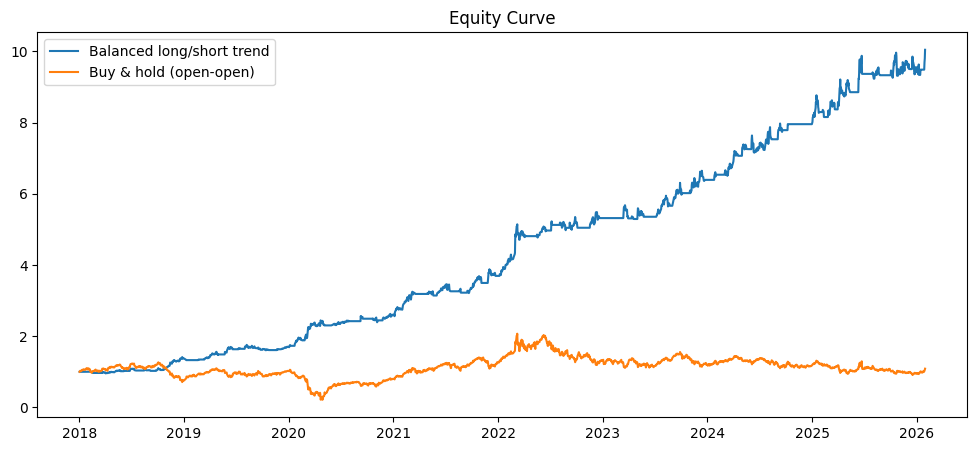

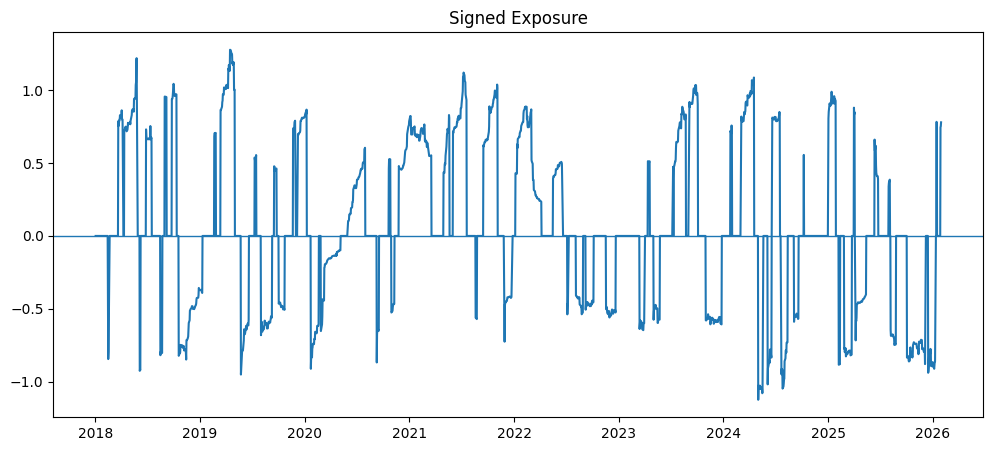

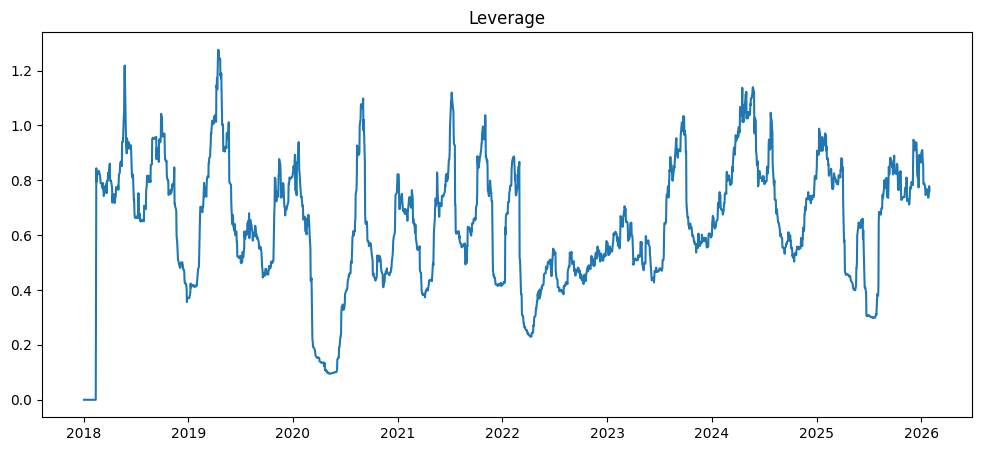

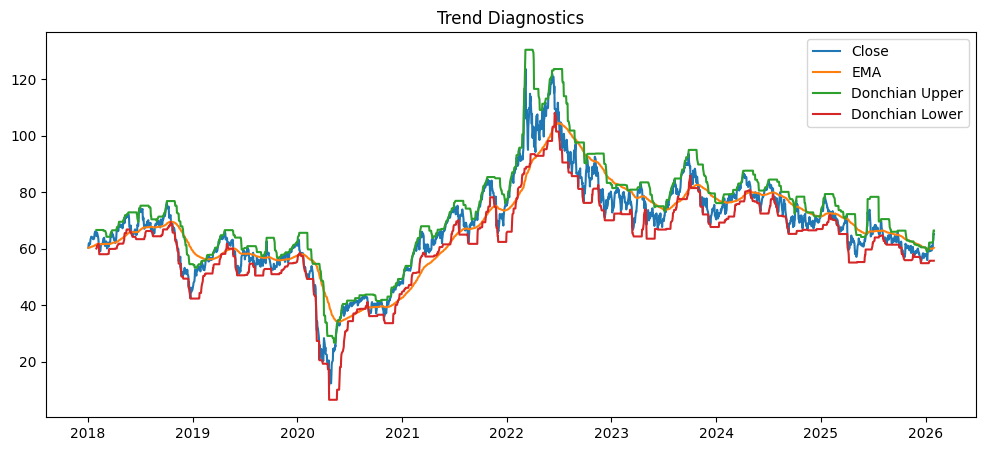

In [9]:
# -----------------------------
# Plots
# -----------------------------
plt.figure()
plt.plot(bt.index, bt["Equity"], label="Balanced long/short trend")
plt.plot(bt.index, bt["bh_equity"], label="Buy & hold (open-open)")
plt.title("Equity Curve")
plt.legend()
plt.show()

plt.figure()
plt.plot(bt.index, bt["exposure"])
plt.axhline(0, linewidth=1)
plt.title("Signed Exposure")
plt.show()

plt.figure()
plt.plot(bt.index, bt["lev"])
plt.title("Leverage")
plt.show()

plt.figure()
plt.plot(bt.index, bt["Close"], label="Close")
plt.plot(bt.index, bt["EMA"], label="EMA")
plt.plot(bt.index, bt["DONCH_UP"], label="Donchian Upper")
plt.plot(bt.index, bt["DONCH_DN"], label="Donchian Lower")
if bt["STOP_LEVEL"].notna().any():
    plt.plot(bt.index, bt["STOP_LEVEL"], label="ATR Stop", alpha=0.8)
plt.title("Trend Diagnostics")
plt.legend()
plt.show()


In [10]:
equity_export = bt["Equity"].rename("Equity").reset_index()
equity_export.columns = ["Date", "Equity"]
equity_export.to_csv(OUTPUT_CSV, index=False)
print(f"Saved balanced trend equity curve to {OUTPUT_CSV}")
equity_export.tail()


Saved balanced trend equity curve to ../../portfolio/data/trend-long-short-futures-balanced.csv


,Date,Equity
2033,2026-01-26,9.486321
2034,2026-01-27,9.486321
2035,2026-01-28,9.693566
2036,2026-01-29,9.800550
2037,2026-01-30,10.044434
